In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
hddataset = pd.read_csv('Heart Disease Dataset.csv') #reading our csv file

In [ ]:
hddataset.head(5) # checking top 5 rows

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
hddataset.shape #dimension

(1025, 14)

In [ ]:
hddataset.describe() #to find summary of data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
hddataset.dtypes #shows the data type of each column

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
hddataset.isnull().sum() #to count missing values per column.

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
hddataset.duplicated() #to see the duplicate rows.

,0
0,False
1,False
2,False
3,False
4,False
...,...
1020,True
1021,True
1022,True
1023,True


In [ ]:
hddataset.duplicated().sum() #to count the total number of duplicates

np.int64(723)

In [ ]:
hddataset.drop_duplicates(inplace = True) #dropping the duplicate values
#checking the count after dropping duplicates
hddataset.duplicated().sum()

np.int64(0)

In [ ]:
#checking the dimension of cleaned dataset
hddataset.shape

(302, 14)

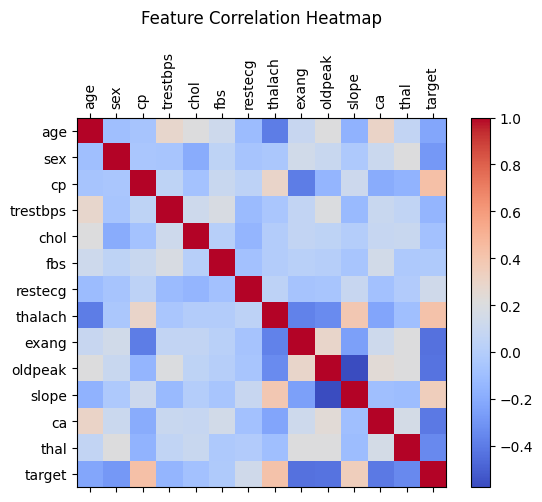

In [ ]:
#Diagram for Feauture Correlation Matrix
corr = hddataset.select_dtypes(include=['number']).corr() #so it takes only numerical columns, not new columns like age interval

fig, ax = plt.subplots()
cax = ax.matshow(corr, cmap='coolwarm')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(cax)
plt.title('Feature Correlation Heatmap', pad=20)
plt.show()


In [ ]:
#Studying the average cholesterol in different age groups
bins = [20, 40, 60, 80]
labels = ['21-40', '41-60', '61-80']
hddataset['age_interval'] = pd.cut(hddataset['age'], bins=bins, labels=labels) # creating an age_interval column

/tmp/ipython-input-2341228503.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_0 = hddataset.groupby(['age_interval'])['chol'].mean() #calculating mean cholesterol for each age_interval


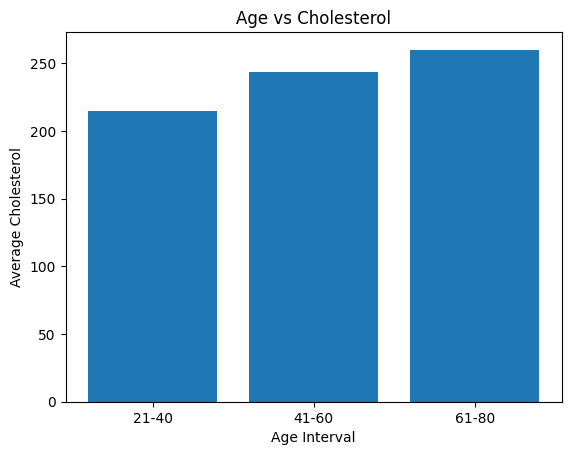

In [ ]:
#Grouping the data with respect to age_interval
grouped_data_0 = hddataset.groupby(['age_interval'])['chol'].mean() #calculating mean cholesterol for each age_interval

#Plotting the barchart
fig, ax = plt.subplots()

ax.bar(grouped_data_0.index.categories, grouped_data_0.values)
ax.set_ylabel('Average Cholesterol')
ax.set_xlabel('Age Interval')
ax.set_title('Age vs Cholesterol')

plt.show()

/tmp/ipython-input-2578522091.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_1 = hddataset.groupby(['age_interval'])['thalach'].mean() #calculating mean max HR for each age_interval


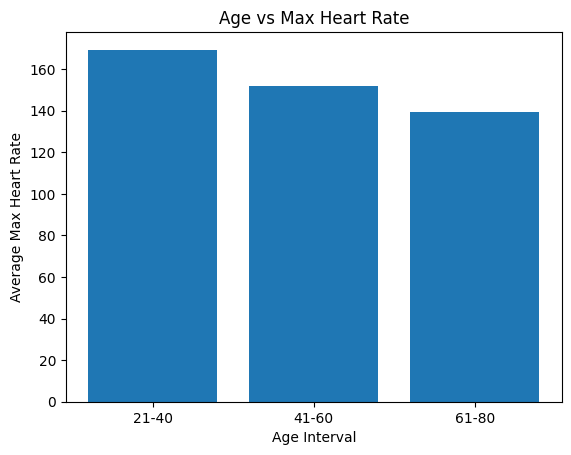

In [ ]:
#Studying the average thalach(maximum heart rate achieved during exercise) in different age groups
#Grouping the data with respect to age_interval
grouped_data_1 = hddataset.groupby(['age_interval'])['thalach'].mean() #calculating mean max HR for each age_interval

#Plotting the barchart
fig, ax = plt.subplots()

ax.bar(grouped_data_1.index.categories, grouped_data_1.values)
ax.set_ylabel('Average Max Heart Rate')
ax.set_xlabel('Age Interval')
ax.set_title('Age vs Max Heart Rate')

plt.show()

target         0    1
age_interval         
21-40          6   12
41-60         88  117
61-80         44   35


/tmp/ipython-input-980832051.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_new = hddataset.groupby(['age_interval', 'target']).size().unstack(fill_value=0)


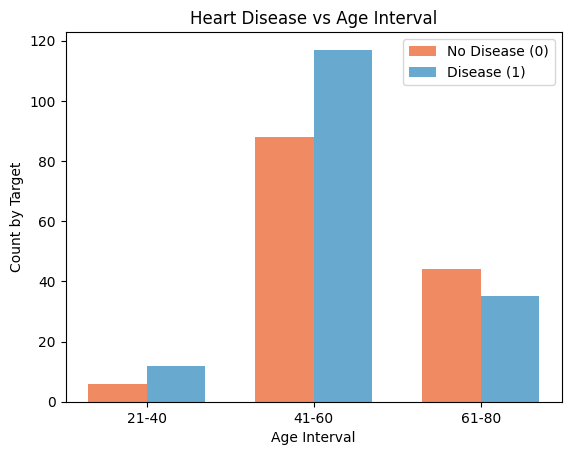

In [ ]:
#grouped bar chart -- Target vs Age
#Target is 0 for No Disease, 1 for Disease
grouped_data_new = hddataset.groupby(['age_interval', 'target']).size().unstack(fill_value=0)
print(grouped_data_new)

#Plotting the barchart
x = np.arange(len(grouped_data_new))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, grouped_data_new[0], width, color="#ef8a62",label="No Disease (0)")
ax.bar(x + width/2, grouped_data_new[1], width, color="#67a9cf",label="Disease (1)")

ax.set_ylabel('Count by Target')
ax.set_xlabel('Age Interval')
ax.set_title('Heart Disease vs Age Interval')
ax.set_xticks(x)
ax.set_xticklabels(grouped_data_new.index.categories)
ax.legend()

#plt.tight_layout()
plt.show()

/tmp/ipython-input-3362048598.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data_new = hddataset.groupby(['age_interval', 'target']).size().unstack(fill_value=0) #df already exists


target                0          1
age_interval                      
21-40         33.823529  66.176471
41-60         45.985401  54.014599
61-80         59.191176  40.808824


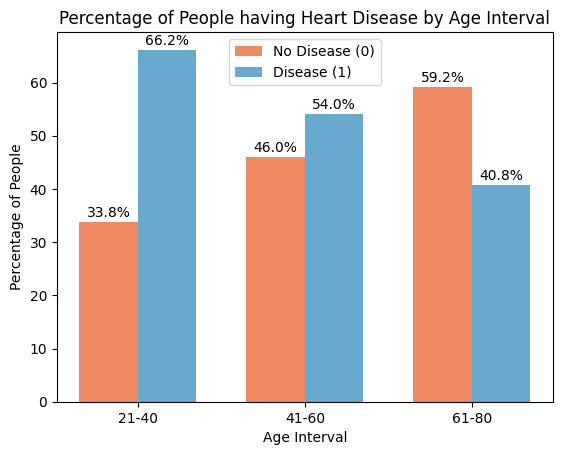

In [ ]:
#Creating the same bar chart with percentages instead of counts
grouped_data_new = hddataset.groupby(['age_interval', 'target']).size().unstack(fill_value=0) #df already exists

# Convert counts to percentages (row-wise)
grouped_data_pct = grouped_data_new.div(grouped_data_new.sum(axis=1), axis=0) * 100

print(grouped_data_pct)

# Plotting the bar chart
x = np.arange(len(grouped_data_pct))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, grouped_data_pct[0], width, color="#ef8a62", label="No Disease (0)")
ax.bar(x + width/2, grouped_data_pct[1], width, color="#67a9cf", label="Disease (1)")

ax.set_ylabel('Percentage of People')
ax.set_xlabel('Age Interval')
ax.set_title('Percentage of People having Heart Disease by Age Interval')
ax.set_xticks(x)
ax.set_xticklabels(grouped_data_pct.index.categories)
ax.legend()

# Show percentage values on top of bars
for i in range(len(x)):
    ax.text(x[i] - width/2, grouped_data_pct.iloc[i, 0] + 1, f"{grouped_data_pct.iloc[i, 0]:.1f}%", ha='center')
    ax.text(x[i] + width/2, grouped_data_pct.iloc[i, 1] + 1, f"{grouped_data_pct.iloc[i, 1]:.1f}%", ha='center')

#plt.tight_layout()
plt.show()

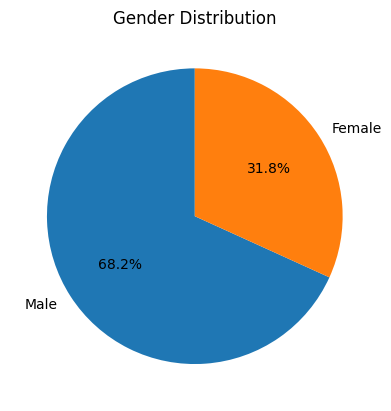

In [ ]:
#Pie Chart for Gender
counts = hddataset['sex'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts, labels=['Male', 'Female'], autopct='%1.1f%%', startangle=90)
ax.set_title('Gender Distribution')

plt.show()

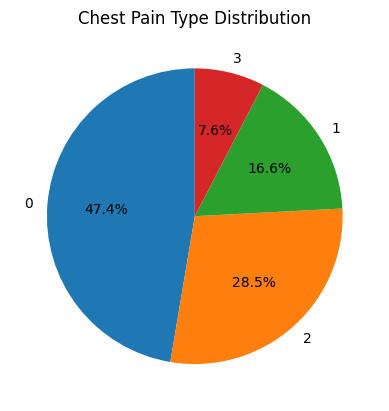

In [ ]:
#Pie Chart for Chest Pain
counts_2 = hddataset['cp'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts_2, labels=counts_2.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Chest Pain Type Distribution')

plt.show()

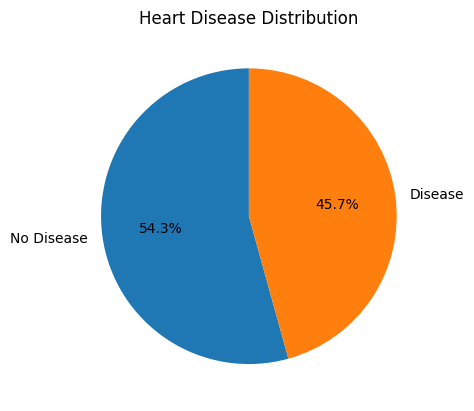

In [ ]:
#Pie Chart for Heart Disease
counts_3 = hddataset['target'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts_3, labels=['No Disease','Disease'], autopct='%1.1f%%', startangle=90)
ax.set_title('Heart Disease Distribution')

plt.show()

sex   0    1
cp          
0    39  104
1    18   32
2    35   51
3     4   19


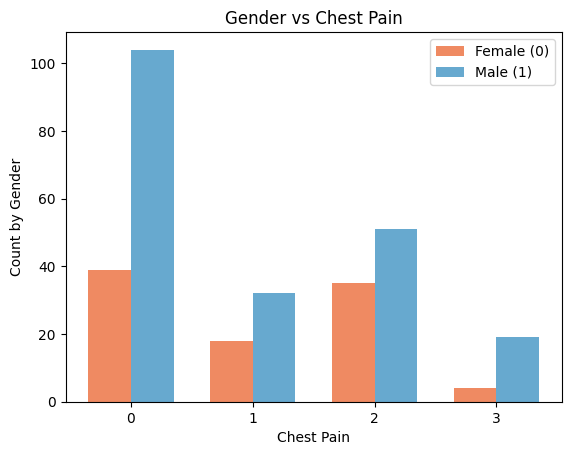

In [ ]:
#grouped bar chart -- Gender vs Chest Pain

grouped_data_5 = hddataset.groupby(['cp', 'sex']).size().unstack(fill_value=0)
print(grouped_data_5)

#Plotting the barchart
x = np.arange(len(grouped_data_5))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, grouped_data_5[0], width, color="#ef8a62",label="Female (0)")
ax.bar(x + width/2, grouped_data_5[1], width, color="#67a9cf",label="Male (1)")

ax.set_ylabel('Count by Gender')
ax.set_xlabel('Chest Pain')
ax.set_title('Gender vs Chest Pain')
ax.set_xticks(x)
ax.set_xticklabels(grouped_data_5.index)
ax.legend()

plt.show()

target    0   1
cp             
0       104  39
1         9  41
2        18  68
3         7  16


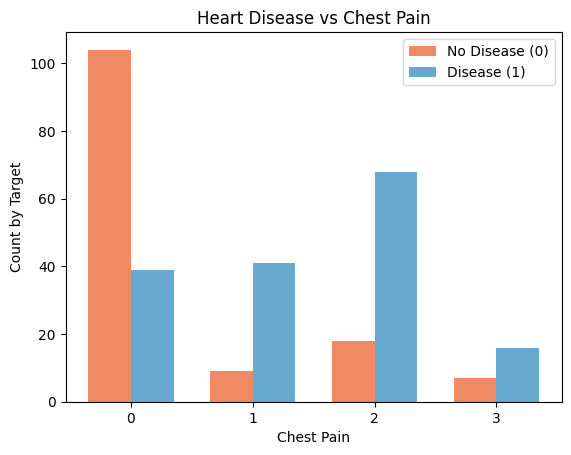

In [ ]:
#grouped bar chart -- Target vs Chest Pain

grouped_data_6 = hddataset.groupby(['cp', 'target']).size().unstack(fill_value=0)
print(grouped_data_6)

#Plotting the barchart
x = np.arange(len(grouped_data_6))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, grouped_data_6[0], width, color="#ef8a62",label="No Disease (0)")
ax.bar(x + width/2, grouped_data_6[1], width, color="#67a9cf",label="Disease (1)")

ax.set_ylabel('Count by Target')
ax.set_xlabel('Chest Pain')
ax.set_title('Heart Disease vs Chest Pain')
ax.set_xticks(x)
ax.set_xticklabels(grouped_data_6.index)
ax.legend()

#plt.tight_layout()
plt.show()

In [ ]:
#Fitting a Linear Regression Model with the most important features
from sklearn.feature_selection import SelectKBest, f_regression

# Features (X) and target (y)
X = hddataset.drop("target", axis=1) # includes all columns except output column
y = hddataset["target"]

#Feature Selection
selector = SelectKBest(score_func=f_regression, k=4)
selector.fit(X, y)

#creating a dataframe with each feature and their f-score sorted in descending order
feature_scores = pd.DataFrame({'feature': X.columns,'score': selector.scores_}).sort_values('score', ascending=False)

print(feature_scores)

     feature       score
9    oldpeak  243.450780
8      exang  242.883889
2         cp  238.558457
7    thalach  222.799538
11        ca  174.877078
10     slope  138.679393
12      thal  131.802996
1        sex   86.689707
0        age   56.785135
3   trestbps   20.087353
6    restecg   18.838205
4       chol   10.326152
5        fbs    1.736352


In [ ]:
#Based on the above result, we select the top 7 features and create our new dataset
selected_features = ['exang', 'cp', 'thalach', 'oldpeak', 'slope','ca','thal']

X_new = hddataset[selected_features]
y_new = hddataset['target']

In [ ]:
# Train-test split (70% training data, 30% testing data)
from sklearn.model_selection import train_test_split
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.3, random_state=42)


In [ ]:
#Fitting the linear model
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_new_train, y_new_train)

LinearRegression()

In [ ]:
#testing the model prediction and accuraccy
from sklearn.metrics import r2_score, mean_squared_error

y_new_pred = lin_model.predict(X_new_test)

print("R²:", r2_score(y_new_test, y_new_pred))

R²: 0.42196703750831155


This means only 42% of the variation in y is explained by our independent feature variables (X).

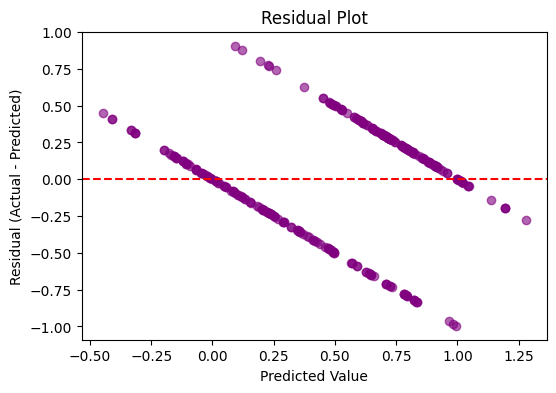

In [ ]:
residuals = y_new_test - y_new_pred

plt.figure(figsize=(6,4))
plt.scatter(y_new_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Value")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

###Interpretation
The R² value is pretty small, which indicates our model is not a very good fit.
Even from the Residual Plot we can see the model mispredicts a lot of values.

This is most likely because our output variable (target) is a binary variable taking values 0 and 1.

Hence it would be much better to fit a Logistic Model instead.

In [ ]:
#Fitting a Logistic Regression Model to our Dataset

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Features (X) and target (y)
X = hddataset.drop("target", axis=1) # includes all columns except output column
y = hddataset["target"]


In [ ]:
# Train-test split (70% training data, 30% testing data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [ ]:
#Fiting the logistic model

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
#  Predicting on the test set

y_pred = log_model.predict(X_test)


# checking the accuarcy and performance of the fitted model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8246753246753247

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.75      0.81       150
           1       0.79      0.90      0.84       158

    accuracy                           0.82       308
   macro avg       0.83      0.82      0.82       308
weighted avg       0.83      0.82      0.82       308


Confusion Matrix:
 [[112  38]
 [ 16 142]]


##Interpretation of above results
### For Class 0 (No Heart Disease)
Precision: 0.88 means out of all predicted “no disease”, 88% were really no disease.

Recall: 0.75 means out of all actual “no disease” cases, the model correctly found 75%.

It missed 25% of them → that matches the 38 false positives.

F1-score: 0.81 gives a balance of precision & recall (the higher the better)

### For Class 1 (With Heart Disease)
Precision: 0.79 means when the model predicts “disease”, it is correct 79% of the time.

It still has 21% false alarms.

Recall: 0.90 means the model catches 90% of patients who actually have heart disease.

Only 16 are False Negatives out of 158.

F1-score: 0.84

###This means our model performance is overall good.

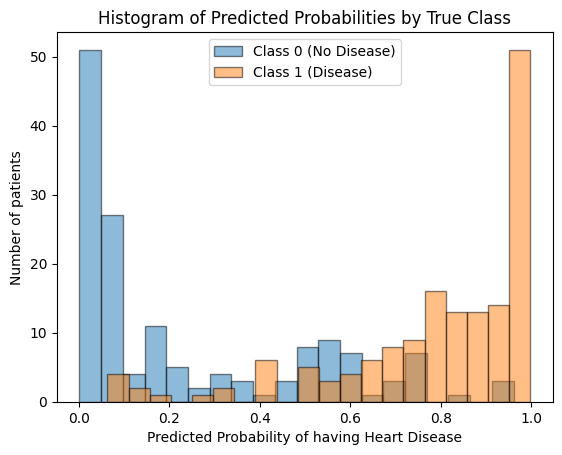

In [ ]:
## Plotting the Model Performance

# Predicted probabilities
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

# Split by true class
proba_class0 = y_pred_proba[y_test == 0]
proba_class1 = y_pred_proba[y_test == 1]

plt.hist(proba_class0, bins=20, alpha=0.5, label='Class 0 (No Disease)', edgecolor='k')
plt.hist(proba_class1, bins=20, alpha=0.5, label='Class 1 (Disease)', edgecolor='k')
plt.xlabel('Predicted Probability of having Heart Disease')
plt.ylabel('Number of patients')
plt.title('Histogram of Predicted Probabilities by True Class')
plt.legend()
plt.show()

###Interpretation of the Graph

As we can see from the graph, most of the actual patients with no disease (blue bars) have been predicted to have low probability of having the disease.

Similarly, most of the actual patients with the disease (orange bars) have been predicted to have high probability of having the disease.

Although there are some overlaps, majority of the time the model prediction is accurate.